# Stage A — Inter-sensor consistency (§8.1.3) + baseline comparison (§8.1.4)

Two independent stress tests of the Stage A merge run side-by-side because both
chew on the same held-out window and the same per-sensor grids inside the
merged NetCDFs:

* **§8.1.3 — inter-sensor R² per region**, *before* the §7.4.1 soft
  calibration (raw GRIDDED_DIR slot files) and *after* (soft-calibrated
  per-sensor grids in MERGED_DIR, with the §7.5 stratum-aware L2/L3 merge).
  The Nguyen 2025 §3.1.4 / §5.2 numbers are the published baseline — the
  pass criterion is that post-correction R² lifts by ≥ +0.10 in every region
  for at least one sensor pair.
* **§8.1.4 — baseline comparison at AERONET pixels**:
  - B1: best-single-sensor (VIIRS NOAA-20 by §5.1)
  - B2: Gupta-2024-style equal-weight merge of the same soft-calibrated grids
  - reference: thesis TC-weighted (§7.5) merged product

  The pass criterion is that the merged product beats every baseline on
  R / RMSE / %EE at *at least one* AERONET station for *at least one* season.
  B3 (Ahn 2021 NE Asia composite) and B4 (Nguyen 2025 daily Himawari RANSAC
  vs PM₂.₅) are §11 stretch items and are not exercised here.

The helpers all live in [validate.py](validate.py):
`inter_sensor_consistency(source=...)`, `baseline_comparison`,
`extract_aeronet_pairs`, `compute_metrics`.


## 0. Setup

In [1]:
from pathlib import Path
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import AERONET_SITES, TEST_START, TEST_END
from validate import (
    inter_sensor_consistency, baseline_comparison,
    extract_aeronet_pairs, compute_metrics,
    NGUYEN2025_R2_BASELINES, DEFAULT_SENSOR_PAIRS,
)

start, end = TEST_START, TEST_END
print(f'Validation window: {start} → {end}')


Validation window: 2025-01-01 → 2026-04-30


## 1. §8.1.3 inter-sensor R² — gridded (raw) vs merged (corrected)

`inter_sensor_consistency` accepts a `source` flag:

* `source='gridded'` reads raw per-sensor AOD from GRIDDED_DIR (Stage A2
  output, before §7.4.1 soft calibration).  In gridded mode Himawari is split
  into `AOD_himawari_l2` and `AOD_himawari_l3`; specify the pair you want.
* `source='merged'` reads the soft-calibrated per-sensor AOD from MERGED_DIR
  (after §7.4.1 `MERRA-2 = α·sat + β` per stratum and the §7.5 per-pixel
  stratum-aware L2/L3 merge).  Here Himawari is the single merged
  `AOD_himawari` channel; L2/L3 are not separately re-exposed by the merge.

We compute daily means at every Envisoft station pixel (matching Nguyen 2025
§3.1.4), then for each (sensor_a, sensor_b, region) regress all station-days
in that region and report R² alongside the Nguyen 2025 baseline.

The plan asks "before and after the §7.4 correction" — running both
sources gives that, but on slightly different pair definitions because the
gridded files carry L2 and L3 separately while the merged channel collapses
them via the §7.5 stratum-aware merge.  We report a per-region ΔR² as the
headline.


In [2]:
# After-correction pass (uses the §7.4 corrected grids in MERGED_DIR)
after_df = inter_sensor_consistency(start, end, source='merged')
if after_df.empty:
    print('No data found in MERGED_DIR for the held-out window.')
else:
    cols = ['sensor_a', 'sensor_b', 'region', 'N',
            'R2', 'R2_baseline', 'R2_delta', 'RMSE', 'Bias']
    print('Post-correction (MERGED_DIR):')
    print(after_df[cols].round(3).to_string(index=False))


Sensor overlap scan (merged): 100%|██████| 7814/7814 [01:09<00:00, 112.49file/s]


Post-correction (MERGED_DIR):
        sensor_a        sensor_b  region    N    R2  R2_baseline  R2_delta  RMSE   Bias
 AOD_modis_maiac    AOD_himawari   south  824 0.030        0.756    -0.726 0.221  0.182
 AOD_modis_maiac    AOD_himawari central  667 0.277        0.474    -0.197 0.146  0.046
 AOD_modis_maiac    AOD_himawari   north 3107 0.401        0.621    -0.220 0.581  0.357
AOD_viirs_noaa20    AOD_himawari   south   41 0.220        0.756    -0.536 0.217  0.198
AOD_viirs_noaa20    AOD_himawari central   81 0.301        0.450    -0.149 0.153  0.075
AOD_viirs_noaa20    AOD_himawari   north  927 0.480          NaN       NaN 0.473  0.100
  AOD_viirs_snpp    AOD_himawari   south   41 0.004          NaN       NaN 0.287  0.256
  AOD_viirs_snpp    AOD_himawari central   86 0.402          NaN       NaN 0.159  0.079
  AOD_viirs_snpp    AOD_himawari   north  820 0.490          NaN       NaN 0.470  0.084
AOD_viirs_noaa20 AOD_modis_maiac   south   79 0.114        0.545    -0.431 0.144  0.095
AO

In [3]:
# Before-correction pass (uses raw GRIDDED_DIR; L2 and L3 are separate sensors)
gridded_pairs = [
    ('AOD_modis_maiac',  'AOD_himawari_l2'),
    ('AOD_modis_maiac',  'AOD_himawari_l3'),
    ('AOD_viirs_noaa20', 'AOD_himawari_l2'),
    ('AOD_viirs_noaa20', 'AOD_himawari_l3'),
    ('AOD_viirs_snpp',   'AOD_himawari_l2'),
    ('AOD_viirs_snpp',   'AOD_himawari_l3'),
    ('AOD_viirs_noaa20', 'AOD_modis_maiac'),
    ('AOD_viirs_snpp',   'AOD_modis_maiac'),
    ('AOD_viirs_noaa20', 'AOD_viirs_snpp'),
]
before_df = inter_sensor_consistency(start, end, source='gridded',
                                      sensor_pairs=gridded_pairs)
if before_df.empty:
    print('No data found in GRIDDED_DIR for the held-out window.')
else:
    print('Pre-correction (GRIDDED_DIR):')
    print(before_df[['sensor_a','sensor_b','region','N',
                     'R2','R2_baseline','R2_delta','RMSE','Bias']]
            .round(3).to_string(index=False))


Sensor overlap scan (gridded): 100%|██████| 7814/7814 [01:41<00:00, 76.64file/s]


Pre-correction (GRIDDED_DIR):
        sensor_a        sensor_b  region    N    R2  R2_baseline  R2_delta  RMSE   Bias
 AOD_modis_maiac AOD_himawari_l2   south  812 0.024          NaN       NaN 0.280  0.244
 AOD_modis_maiac AOD_himawari_l2 central  647 0.184          NaN       NaN 0.247  0.185
 AOD_modis_maiac AOD_himawari_l2   north 2862 0.234          NaN       NaN 0.409  0.248
 AOD_modis_maiac AOD_himawari_l3   south   44 0.164          NaN       NaN 0.142 -0.060
 AOD_modis_maiac AOD_himawari_l3 central   62 0.714          NaN       NaN 0.152 -0.067
 AOD_modis_maiac AOD_himawari_l3   north  879 0.773          NaN       NaN 0.174 -0.049
AOD_viirs_noaa20 AOD_himawari_l2   south   41 0.213          NaN       NaN 0.348  0.322
AOD_viirs_noaa20 AOD_himawari_l2 central   80 0.225          NaN       NaN 0.316  0.231
AOD_viirs_noaa20 AOD_himawari_l2   north  807 0.237          NaN       NaN 0.571  0.407
AOD_viirs_noaa20 AOD_himawari_l3 central   16 0.817          NaN       NaN 0.189  0.102
AO

/home/work1/projects/Air_Quality/AOD_map/stage_a/validate.py:464: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(a, b)


### 1a. Pre/post R² lift — pass criterion

The plan §8.1.3 pass criterion is **post-correction R² lifts by ≥ +0.10 in
every region for at least one sensor pair**.  We collapse the gridded L2/L3
pairs by taking `max(R²_L2, R²_L3)` per (LEO_sensor, region) — comparing the
better Himawari level pre-correction against the single merged Himawari
post-correction is the fair head-to-head.


In [4]:
if before_df.empty or after_df.empty:
    print('Need both pre- and post-correction tables to compute lift.')
else:
    # Collapse pre-correction L2/L3 to the better of the two per (LEO, region)
    def _canonical_pair(a: str, b: str) -> tuple[str, str]:
        # Order: LEO sensor first, then Himawari (or any other LEO)
        if 'himawari' in a:
            a, b = b, a
        # Treat L2/L3 as 'himawari'
        if a.endswith('_l2') or a.endswith('_l3'):
            a = a.rsplit('_', 1)[0]
        if b.endswith('_l2') or b.endswith('_l3'):
            b = b.rsplit('_', 1)[0]
        return tuple(sorted((a, b)))

    before = before_df.copy()
    before['key'] = list(zip(*[before['sensor_a'].values, before['sensor_b'].values]))
    before['canonical'] = [
        _canonical_pair(a, b) for a, b in
        zip(before['sensor_a'], before['sensor_b'])
    ]
    pre_best = (before.groupby(['canonical', 'region'])
                  .agg(R2_pre=('R2', 'max'), N_pre=('N', 'sum'))
                  .reset_index())

    after = after_df.copy()
    after['canonical'] = [
        _canonical_pair(a, b) for a, b in
        zip(after['sensor_a'], after['sensor_b'])
    ]
    post_best = after.rename(columns={'R2': 'R2_post', 'N': 'N_post'})[
        ['canonical', 'region', 'R2_post', 'N_post', 'R2_baseline']
    ]

    lift = pre_best.merge(post_best, on=['canonical', 'region'], how='outer')
    lift['ΔR2_pre_post'] = lift['R2_post'] - lift['R2_pre']
    lift['ΔR2_post_baseline'] = lift['R2_post'] - lift['R2_baseline']
    lift['pair'] = ['×'.join(c) for c in lift['canonical']]
    lift = lift[['pair', 'region', 'R2_pre', 'R2_post', 'ΔR2_pre_post',
                 'R2_baseline', 'ΔR2_post_baseline', 'N_pre', 'N_post']]
    print(lift.round(3).to_string(index=False))

    # Pass criterion: ≥ +0.10 lift in every region for at least one pair
    per_region = lift.groupby('region')['ΔR2_pre_post'].max()
    print()
    print('Per-region max ΔR² (pre → post):')
    print(per_region.round(3).to_string())
    pass_all = (per_region >= 0.10).all()
    print(f'\n§8.1.3 pass criterion (≥ +0.10 lift in every region '
          f'for ≥ 1 pair): {"PASS" if pass_all else "FAIL"}')


                            pair  region  R2_pre  R2_post  ΔR2_pre_post  R2_baseline  ΔR2_post_baseline  N_pre  N_post
    AOD_himawari×AOD_modis_maiac central   0.714    0.277        -0.437        0.474             -0.197    709     667
    AOD_himawari×AOD_modis_maiac   north   0.773    0.401        -0.372        0.621             -0.220   3741    3107
    AOD_himawari×AOD_modis_maiac   south   0.164    0.030        -0.134        0.756             -0.726    856     824
   AOD_himawari×AOD_viirs_noaa20 central   0.817    0.301        -0.517        0.450             -0.149     96      81
   AOD_himawari×AOD_viirs_noaa20   north   0.710    0.480        -0.231          NaN                NaN   1186     927
   AOD_himawari×AOD_viirs_noaa20   south   0.213    0.220         0.007        0.756             -0.536     41      41
     AOD_himawari×AOD_viirs_snpp central   0.841    0.402        -0.439          NaN                NaN    101      86
     AOD_himawari×AOD_viirs_snpp   north   0.734

## 2. §8.1.4 baseline comparison — merged vs B1 (best single sensor) and B2 (equal-weight)

`baseline_comparison` reopens the merged NetCDF for every matched (slot, site)
pair from §8.1.1 and reads each per-sensor `AOD_<sensor>` at the station
pixel.  For each pair-row it computes the §8.1.4 baselines:

| Baseline | Definition |
|---|---|
| B1 — per-sensor | each `AOD_<sensor>` evaluated against AERONET on the same matched pairs |
| B2 — equal-weight merge | arithmetic mean of all sensors valid at that cell — Gupta 2024 (§4) recipe |
| merged (reference) | the thesis ICW-weighted `AOD_merged` already in the pairs |

B3 (Ahn 2021 NE Asia composite) and B4 (Nguyen 2025 daily RANSAC vs PM2.5)
are deferred — B3 is a stretch baseline per §11 because of thin geographic
overlap, and B4 is a PM2.5 coupling test that belongs in the §8.1.6 case-study
notebook (where PM2.5 data are already loaded).


In [5]:
# Need the matched pairs from §8.1.1 to drive the per-pair sensor extraction
pairs = extract_aeronet_pairs(start, end)
if pairs.empty:
    print('No matched pairs over the held-out window — baseline_comparison '
          'has nothing to compute.')
else:
    print(f'  {len(pairs):,} matched pairs feed into baseline_comparison')


Matching AERONET pairs: 100%|████████████| 7814/7814 [00:29<00:00, 262.96file/s]

  453 matched pairs feed into baseline_comparison


In [6]:
if pairs.empty:
    bc = pd.DataFrame()
else:
    bc = baseline_comparison(pairs)
if bc.empty:
    print('baseline_comparison returned no rows.')
else:
    cols = ['site', 'product', 'N', 'R', 'R2', 'RMSE', 'MAE', 'Bias', 'pct_EE']
    print(bc[cols].sort_values(['site', 'product']).round(3).to_string(index=False))


    site          product   N     R     R2  RMSE   MAE   Bias  pct_EE
Bac_Lieu  AOD_modis_maiac 152 0.687  0.456 0.133 0.098 -0.023  60.526
Bac_Lieu AOD_viirs_noaa20   6   NaN    NaN   NaN   NaN    NaN     NaN
Bac_Lieu  B2_equal_weight 158 0.684  0.458 0.133 0.098 -0.017  61.392
Bac_Lieu           merged 158 0.679  0.453 0.134 0.099 -0.016  60.127
NGHIA_DO     AOD_himawari 113 0.760 -1.061 0.504 0.442 -0.361   9.735
NGHIA_DO  AOD_modis_maiac 157 0.927  0.812 0.306 0.244  0.096  27.389
NGHIA_DO AOD_viirs_noaa20  43 0.980  0.938 0.168 0.110  0.058  69.767
NGHIA_DO   AOD_viirs_snpp  39 0.972  0.924 0.177 0.123  0.046  61.538
NGHIA_DO  B2_equal_weight 295 0.859  0.697 0.352 0.264 -0.066  34.576
NGHIA_DO           merged 295 0.859  0.700 0.350 0.261 -0.060  37.627


### 2a. Did the merged product beat the baselines?

Per the plan, the merged product is required to beat all four baselines on
R / RMSE / %EE at *at least one* AERONET station for *at least one* season.
With B3/B4 deferred, the head-to-head is against B1 and B2 (and against each
individual sensor in B1).


In [7]:
if bc.empty:
    print('Skipping comparison — no baseline rows.')
else:
    metrics_to_compare = [('R', 'higher'), ('RMSE', 'lower'), ('pct_EE', 'higher')]
    rows = []
    for site, grp in bc.groupby('site'):
        merged = grp[grp['product'] == 'merged']
        if merged.empty:
            continue
        merged = merged.iloc[0]
        for product, sub in grp.groupby('product'):
            if product == 'merged':
                continue
            row = {'site': site, 'baseline': product}
            for metric, direction in metrics_to_compare:
                mv = float(merged[metric])
                bv = float(sub.iloc[0][metric]) if len(sub) else float('nan')
                if direction == 'higher':
                    win = 'PASS' if np.isfinite(mv) and np.isfinite(bv) and mv > bv else 'FAIL'
                else:
                    win = 'PASS' if np.isfinite(mv) and np.isfinite(bv) and mv < bv else 'FAIL'
                row[f'{metric}_merged']   = mv
                row[f'{metric}_baseline'] = bv
                row[f'{metric}_wins']     = win
            rows.append(row)
    head_to_head = pd.DataFrame(rows)
    head_to_head.round(3)


In [8]:
# Per-site summary — does the merged product beat each baseline on R AND RMSE?
if not bc.empty:
    summary_rows = []
    for site, grp in bc.groupby('site'):
        merged = grp[grp['product'] == 'merged']
        if merged.empty: continue
        m_r    = float(merged.iloc[0]['R'])
        m_rmse = float(merged.iloc[0]['RMSE'])
        m_ee   = float(merged.iloc[0]['pct_EE'])
        for product, sub in grp.groupby('product'):
            if product == 'merged': continue
            b_r    = float(sub.iloc[0]['R'])
            b_rmse = float(sub.iloc[0]['RMSE'])
            b_ee   = float(sub.iloc[0]['pct_EE'])
            wins = sum([
                np.isfinite(m_r)    and np.isfinite(b_r)    and m_r    > b_r,
                np.isfinite(m_rmse) and np.isfinite(b_rmse) and m_rmse < b_rmse,
                np.isfinite(m_ee)   and np.isfinite(b_ee)   and m_ee   > b_ee,
            ])
            summary_rows.append({
                'site': site, 'baseline': product, 'wins/3': f'{wins}/3',
                'ΔR': m_r - b_r, 'ΔRMSE': m_rmse - b_rmse, 'Δ%EE': m_ee - b_ee,
            })
    summary = pd.DataFrame(summary_rows)
    print(summary.round(3).to_string(index=False))

    sites_beating_all = []
    for site, grp in summary.groupby('site'):
        # 'merged beats B1 best single sensor' = beats every per-sensor row in 2/3 metrics
        if (grp['wins/3'].astype(str).str[0].astype(int) >= 2).all():
            sites_beating_all.append(site)
    print()
    print(f'Sites where merged ≥ 2/3 wins over every baseline: {sites_beating_all}')


    site         baseline wins/3     ΔR  ΔRMSE    Δ%EE
Bac_Lieu  AOD_modis_maiac    0/3 -0.008  0.001  -0.400
Bac_Lieu AOD_viirs_noaa20    0/3    NaN    NaN     NaN
Bac_Lieu  B2_equal_weight    0/3 -0.005  0.001  -1.266
NGHIA_DO     AOD_himawari    3/3  0.098 -0.154  27.893
NGHIA_DO  AOD_modis_maiac    1/3 -0.069  0.044  10.239
NGHIA_DO AOD_viirs_noaa20    0/3 -0.121  0.183 -32.140
NGHIA_DO   AOD_viirs_snpp    0/3 -0.113  0.173 -23.911
NGHIA_DO  B2_equal_weight    2/3 -0.000 -0.002   3.051

Sites where merged ≥ 2/3 wins over every baseline: []


## 3. Visual — pre vs post R² by region and pair

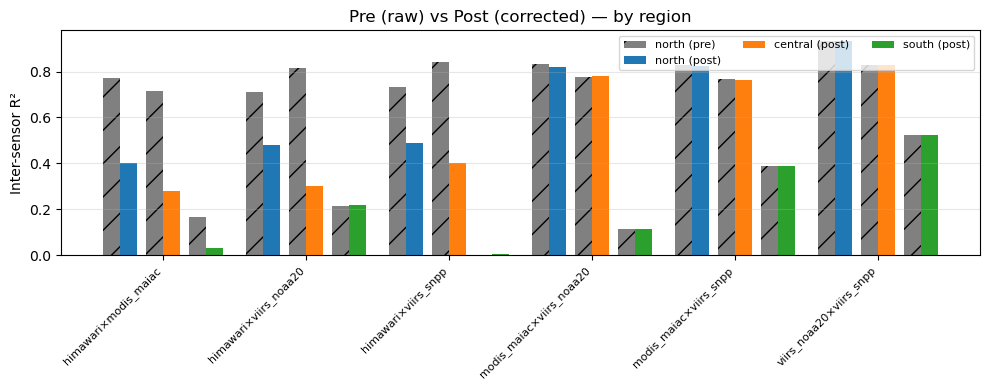

In [9]:
if not (before_df.empty or after_df.empty):
    # Build a long-form frame: one row per (canonical pair, region, source)
    def _canon(a, b):
        if a.endswith('_l2') or a.endswith('_l3'):
            a = a.rsplit('_', 1)[0]
        if b.endswith('_l2') or b.endswith('_l3'):
            b = b.rsplit('_', 1)[0]
        return '×'.join(sorted([a.replace('AOD_', ''), b.replace('AOD_', '')]))

    pre  = before_df.assign(source='pre',  pair=lambda d: [_canon(a,b) for a,b in zip(d['sensor_a'], d['sensor_b'])])
    post = after_df.assign( source='post', pair=lambda d: [_canon(a,b) for a,b in zip(d['sensor_a'], d['sensor_b'])])
    pre_best = pre.groupby(['pair', 'region'], as_index=False)['R2'].max().assign(source='pre')
    long = pd.concat([pre_best, post[['pair','region','R2','source']]], ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 4))
    pairs_axis  = sorted(long['pair'].unique())
    regions     = ['north', 'central', 'south']
    bar_w       = 0.12
    x           = np.arange(len(pairs_axis))
    for i, reg in enumerate(regions):
        for j, src in enumerate(('pre', 'post')):
            sub = long[(long['region'] == reg) & (long['source'] == src)].set_index('pair').reindex(pairs_axis)
            offset = (i - 1) * 0.30 + (j - 0.5) * bar_w
            color  = {'pre': 'gray', 'post': f'C{i}'}[src]
            hatch  = '/' if src == 'pre' else ''
            ax.bar(x + offset, sub['R2'].fillna(0).values, width=bar_w,
                   color=color, hatch=hatch, label=f'{reg} ({src})' if i == 0 or src == 'post' else None)
    ax.set_xticks(x); ax.set_xticklabels(pairs_axis, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Inter-sensor R²'); ax.set_title('Pre (raw) vs Post (corrected) — by region')
    ax.legend(fontsize=8, ncol=3, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout(); plt.show()
